# Stock Market Crash Prediction Using S&P 500 and VIX

## Introduction

Financial market crashes are among the most impactful events in modern economics. They can lead to substantial losses for investors, institutions, and entire economies.

The purpose of this project is to investigate whether machine learning models can identify patterns that precede significant market downturns.

We focus on the S&P 500 index as a representation of the U.S. equity market and the VIX index as a measure of market fear and expected volatility.

The objective is to predict whether a market crash will occur within the next 10 trading days.


## Problem Statement

Given historical information about:

- S&P 500 prices
- Trading volume
- Market volatility through VIX
- Technical indicators
- Rolling risk measures

Can we predict whether the market will experience a significant decline during the next 10 trading days?

In this project, a "crash" event is defined as a future 10-day return less than or equal to -5%.


## Mathematical Background

### Daily Return

Daily return measures the percentage change in asset price between two consecutive trading sessions.

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

### Future Return and Crash Label

The target variable is based on the future 10-day return:

$$
R_{t,t+10} = \frac{P_{t+10}}{P_t} - 1
$$

A crash event is defined as:

$$
Crash_t = \mathbb{1}(R_{t,t+10} \leq -0.05)
$$

This means the model predicts whether the S&P 500 will lose at least 5% over the next 10 trading days.

### Volatility

Volatility measures the dispersion of returns and is often used as a proxy for risk.

$$
\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(r_i - \mu)^2}
$$

### Class Imbalance

Crash events are rare, so the dataset is imbalanced. A model that always predicts "no crash" can have high accuracy but no practical usefulness. Therefore, accuracy is not the main metric in this project.

### Logistic Regression

Logistic regression estimates the probability of a crash event:

$$
P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta^T x)}}
$$

### Precision, Recall and F1-score

$$
Precision = \frac{TP}{TP + FP}
$$

$$
Recall = \frac{TP}{TP + FN}
$$

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

For crash prediction, recall is important because missing a crash can be costly. Precision is also important because too many false alarms make the model hard to use.

### ROC-AUC and Average Precision

ROC-AUC measures how well a model ranks positive examples above negative examples across decision thresholds. Average Precision summarizes the precision-recall curve and is especially useful for imbalanced classification problems.

### Tree Ensembles

Random Forest averages many decision trees trained on bootstrapped samples. This reduces variance and allows nonlinear relationships between features and crash risk.

Gradient Boosting builds trees sequentially, where each new tree focuses on correcting the previous model's errors. XGBoost is an efficient implementation of gradient boosting with regularization and several practical improvements for structured data.

## 1. Setup

Install missing packages if needed:

```bash
pip install yfinance ta xgboost
```


In [530]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

plt.rcParams["figure.figsize"] = (14, 6)
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42


## 1.1 Reusable Helper Functions

To improve maintainability, the main data-processing and evaluation logic is organized into reusable functions. This also makes the notebook easier to test and extend.

In [531]:
def flatten_yfinance_columns(df):
    """Flatten yfinance MultiIndex columns if needed."""
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = df.columns.get_level_values(0)
    return df


def create_features(data):
    """Create trend, momentum, volatility and drawdown features."""
    data = data.copy()

    data["Return"] = data["Close"].pct_change()
    data["VIX_Return"] = data["VIX_Close"].pct_change()

    data["SMA_20"] = data["Close"].rolling(20).mean()
    data["SMA_50"] = data["Close"].rolling(50).mean()
    data["SMA_200"] = data["Close"].rolling(200).mean()
    data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()
    data["EMA_50"] = data["Close"].ewm(span=50, adjust=False).mean()

    data["Momentum_10"] = data["Close"].pct_change(10)
    data["Momentum_20"] = data["Close"].pct_change(20)
    data["Momentum_60"] = data["Close"].pct_change(60)

    data["Volatility_20"] = data["Return"].rolling(20).std()
    data["Volatility_60"] = data["Return"].rolling(60).std()

    rolling_max_252 = data["Close"].rolling(252).max()
    data["Drawdown"] = data["Close"] / rolling_max_252 - 1
    data["Distance_From_SMA_200"] = data["Close"] / data["SMA_200"] - 1

    return data


def create_target(data, horizon=10, threshold=-0.05):
    """Create a binary crash target using a forward return horizon."""
    data = data.copy()
    data["Future_10D_Return"] = data["Close"].shift(-horizon) / data["Close"] - 1
    data["Crash"] = (data["Future_10D_Return"] <= threshold).astype(int)
    return data.dropna()


def sanity_checks(data, features, target="Crash"):
    """Run basic checks that help catch common data problems."""
    assert data.index.is_monotonic_increasing, "Date index must be sorted increasingly."
    assert not data[features].isna().any().any(), "Feature matrix contains missing values."
    assert target in data.columns, f"Missing target column: {target}"
    assert set(data[target].unique()).issubset({0, 1}), "Target must be binary."
    print("Rows:", len(data))
    print("Date range:", data.index.min(), "to", data.index.max())
    print("Crash rate:", round(data[target].mean(), 4))


## 2. Data Collection

I will use Yahoo Finance through the `yfinance` Python package.

Assets:

- `^GSPC`: S&P 500 index
- `^VIX`: CBOE Volatility Index


In [532]:
start_date = "1990-01-01"
end_date = "2026-01-01"

sp500 = yf.download("^GSPC", start=start_date, end=end_date, progress=False, auto_adjust=False)
vix = yf.download("^VIX", start=start_date, end=end_date, progress=False, auto_adjust=False)

sp500 = flatten_yfinance_columns(sp500)
vix = flatten_yfinance_columns(vix)

print("S&P 500 rows:", len(sp500))
print("VIX rows:", len(vix))


S&P 500 rows: 9067
VIX rows: 9067


## 3. Data Preparation

The two time series are joined by date. I keep only dates available for both indices.


In [533]:
sp500 = sp500[["Open", "High", "Low", "Close", "Volume"]].copy()
vix = vix[["Close"]].rename(columns={"Close": "VIX_Close"})

data = sp500.join(vix, how="inner")
data = data.dropna()

data.head()


Price,Open,High,Low,Close,Volume,VIX_Close
Date,,,,,,
1990-01-02,353.399994,359.690002,351.980011,359.690002,162070000,17.240000
1990-01-03,359.690002,360.589996,357.890015,358.760010,192330000,18.190001
1990-01-04,358.760010,358.760010,352.890015,355.670013,177000000,19.219999
1990-01-05,355.670013,355.670013,351.350006,352.200012,158530000,20.110001
1990-01-08,352.200012,354.239990,350.540009,353.790009,140110000,20.260000


## 4. Feature Engineering

I create features that capture trend, momentum, volatility, and market stress.


In [534]:
data = create_features(data)
data.tail()


Price,Open,High,Low,Close,Volume,VIX_Close,Return,VIX_Return,SMA_20,SMA_50,SMA_200,EMA_20,EMA_50,Momentum_10,Momentum_20,Momentum_60,Volatility_20,Volatility_60,Drawdown,Distance_From_SMA_200
Date,,,,,,,,,,,,,,,,,,,,
2025-12-24,6904.910156,6937.319824,6904.910156,6932.049805,1798270000,13.47,0.003221,-0.037857,6842.541968,6784.985977,6260.738538,6830.374860,6769.943258,0.006588,0.024560,0.036419,0.005743,0.008133,0.000000,0.107226
2025-12-26,6936.020020,6945.770020,6921.600098,6929.939941,2586550000,13.60,-0.000304,0.009651,6848.408472,6790.163574,6267.391738,6839.857248,6776.217637,0.004194,0.017222,0.032593,0.005592,0.008125,-0.000304,0.105714
2025-12-29,6903.600098,6920.209961,6888.759766,6905.740234,3541750000,14.20,-0.003492,0.044118,6851.240991,6795.696982,6274.312839,6846.131818,6781.296955,0.011473,0.008271,0.028351,0.005568,0.008142,-0.003795,0.100637
2025-12-30,6900.439941,6913.250000,6893.470215,6896.240234,3309930000,14.33,-0.001376,0.009155,6855.421509,6800.341592,6280.599341,6850.904049,6785.804534,0.011697,0.012273,0.026870,0.005422,0.008145,-0.005166,0.098023
2025-12-31,6898.819824,6901.419922,6844.549805,6845.500000,3261830000,14.95,-0.007358,0.043266,6856.228003,6802.548994,6286.451240,6850.389377,6788.145533,0.006653,0.002362,0.015611,0.005685,0.008197,-0.012485,0.088929


## 5. Target Variable: Crash Definition

The target is equal to 1 when the S&P 500 drops at least 5% over the next 10 trading days.


In [535]:
future_horizon = 10
crash_threshold = -0.05

data = create_target(data, horizon=future_horizon, threshold=crash_threshold)

print(data["Crash"].value_counts())
print(data["Crash"].value_counts(normalize=True))


Crash
0    8417
1     389
Name: count, dtype: int64
Crash
0    0.955826
1    0.044174
Name: proportion, dtype: float64


## 6. Exploratory Data Analysis

I examine the relationship between market price, volatility, and crash labels.


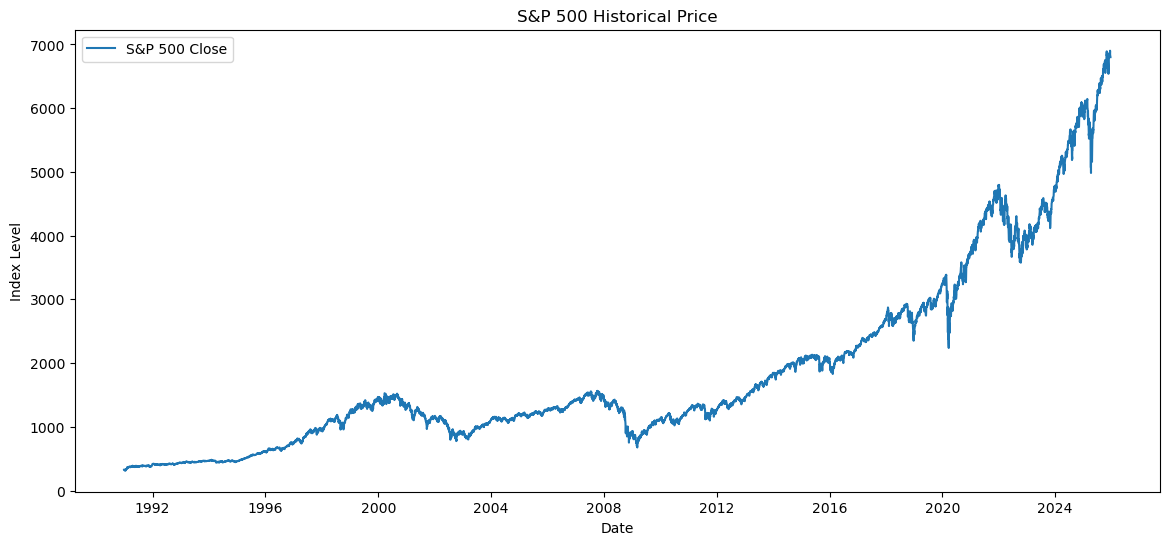

In [536]:
plt.figure(figsize=(14, 6))
plt.plot(data.index, data["Close"], label="S&P 500 Close")
plt.title("S&P 500 Historical Price")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.show()


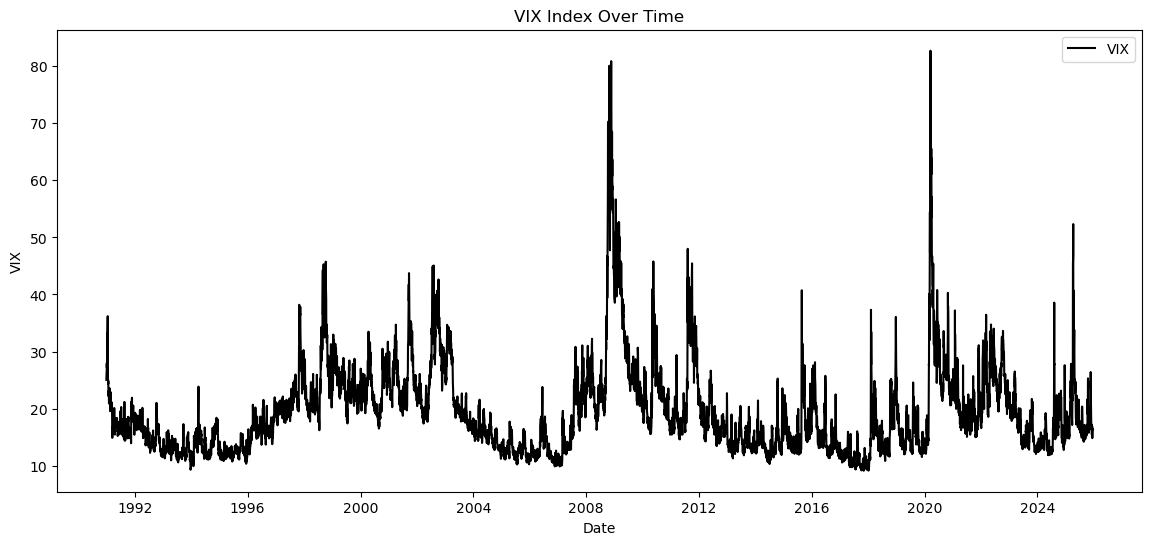

In [537]:
plt.figure(figsize=(14, 6))
plt.plot(data.index, data["VIX_Close"], label="VIX", color="black")
plt.title("VIX Index Over Time")
plt.xlabel("Date")
plt.ylabel("VIX")
plt.legend()
plt.show()


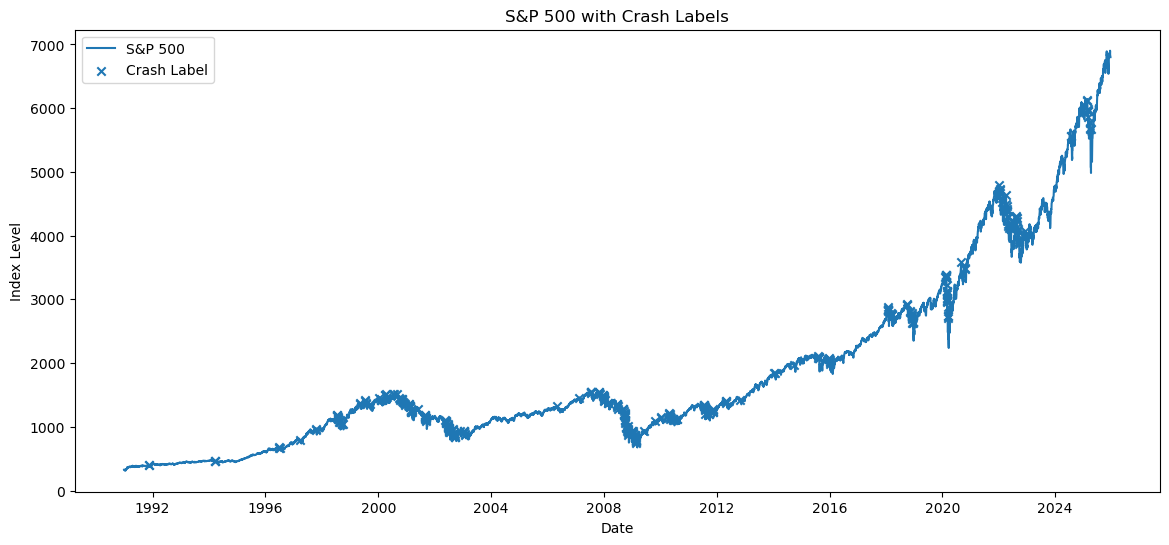

In [538]:
plt.figure(figsize=(14, 6))
plt.plot(data.index, data["Close"], label="S&P 500")
crash_points = data[data["Crash"] == 1]
plt.scatter(crash_points.index, crash_points["Close"], marker="x", label="Crash Label")
plt.title("S&P 500 with Crash Labels")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.show()


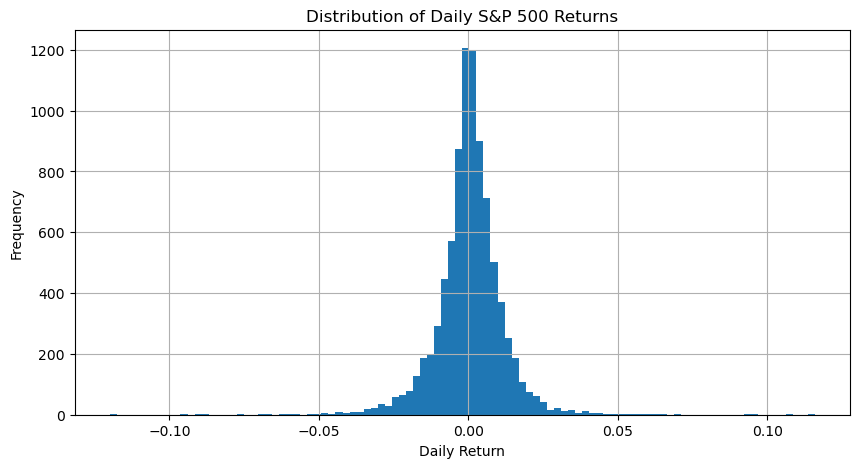

In [539]:
plt.figure(figsize=(10, 5))
data["Return"].hist(bins=100)
plt.title("Distribution of Daily S&P 500 Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()


## 7. Feature Selection


In [540]:
features = [
    "Return",
    "VIX_Close",
    "VIX_Return",
    "SMA_20",
    "SMA_50",
    "SMA_200",
    "EMA_20",
    "EMA_50",
    "Momentum_10",
    "Momentum_20",
    "Momentum_60",
    "Volatility_20",
    "Volatility_60",
    "Drawdown",
    "Distance_From_SMA_200"
]

X = data[features].copy()
y = data["Crash"].copy()

X.head()


sanity_checks(data, features)


Rows: 8806
Date range: 1990-12-28 00:00:00 to 2025-12-16 00:00:00
Crash rate: 0.0442


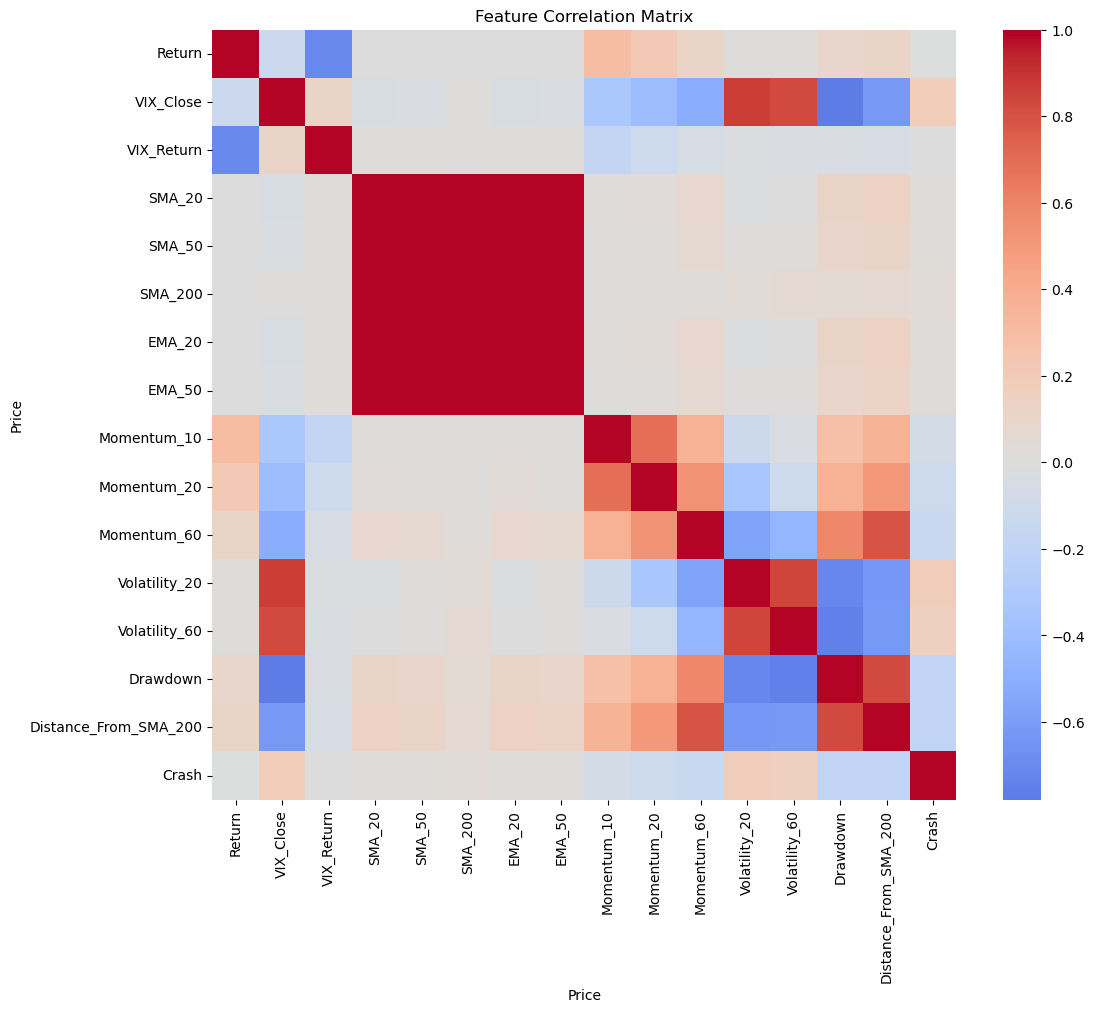

In [541]:
plt.figure(figsize=(12, 10))
sns.heatmap(data[features + ["Crash"]].corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()


## 8. Time-Series Train/Test Split with Leakage Gap

Since this is a time-series problem, the data is not shuffled. The first 80% of observations are used for training and the last 20% for testing.

A 10-trading-day gap is added between the training and testing periods. This is important because the target uses the future 10-day return. Without this gap, the last training labels could depend on prices that belong to the test period, which would create subtle look-ahead leakage.

In [542]:
split_index = int(len(data) * 0.8)
embargo_gap = future_horizon

X_train = X.iloc[:split_index - embargo_gap]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index - embargo_gap]
y_test = y.iloc[split_index:]

print("Train period:", X_train.index.min(), "to", X_train.index.max())
print("Gap period:", X.iloc[split_index - embargo_gap:split_index].index.min(), "to", X.iloc[split_index - embargo_gap:split_index].index.max())
print("Test period:", X_test.index.min(), "to", X_test.index.max())
print("Train crash rate:", round(y_train.mean(), 4))
print("Test crash rate:", round(y_test.mean(), 4))


Train period: 1990-12-28 00:00:00 to 2018-11-27 00:00:00
Gap period: 2018-11-28 00:00:00 to 2018-12-12 00:00:00
Test period: 2018-12-13 00:00:00 to 2025-12-16 00:00:00
Train crash rate: 0.0417
Test crash rate: 0.0494


## 9. Model Evaluation Helper


In [543]:
results = []


def evaluate_model(model_name, y_true, y_pred, y_prob):
    """Evaluate a classifier and store the most important metrics."""
    roc_auc = roc_auc_score(y_true, y_prob)
    avg_precision = average_precision_score(y_true, y_prob)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    results.append({
        "Model": model_name,
        "ROC-AUC": roc_auc,
        "Average Precision": avg_precision,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

    print(f"Model: {model_name}")
    print("-" * 60)
    print(classification_report(y_true, y_pred, zero_division=0))
    print("ROC-AUC:", roc_auc)
    print("Average Precision:", avg_precision)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{model_name}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC Curve - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


## 10. Baseline Model: Majority Class

A simple baseline is necessary because crash events are rare. The baseline predicts the most frequent class only. Any useful model should outperform this baseline, especially on Average Precision, Recall, and F1-score.

Model: Baseline - Majority Class
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1675
           1       0.00      0.00      0.00        87

    accuracy                           0.95      1762
   macro avg       0.48      0.50      0.49      1762
weighted avg       0.90      0.95      0.93      1762

ROC-AUC: 0.5
Average Precision: 0.04937570942111237


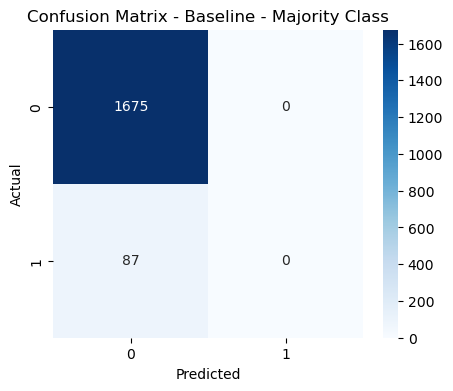

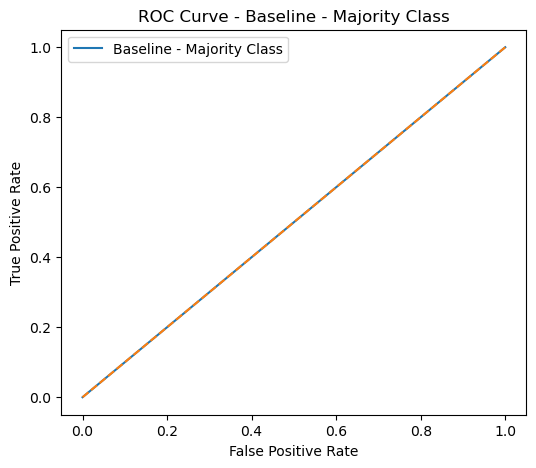

In [544]:
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)

dummy_preds = dummy_model.predict(X_test)
# DummyClassifier still exposes probabilities. The probability for class 1 is used for ranking metrics.
dummy_probs = dummy_model.predict_proba(X_test)[:, list(dummy_model.classes_).index(1)] if 1 in dummy_model.classes_ else np.zeros(len(y_test))

evaluate_model("Baseline - Majority Class", y_test, dummy_preds, dummy_probs)


## 11. Model 1: Logistic Regression

Logistic Regression is used as an interpretable baseline model.


Model: Logistic Regression
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.00      0.00      1675
           1       0.05      1.00      0.09        87

    accuracy                           0.05      1762
   macro avg       0.52      0.50      0.05      1762
weighted avg       0.95      0.05      0.01      1762

ROC-AUC: 0.6361502830674214
Average Precision: 0.06933606321653944


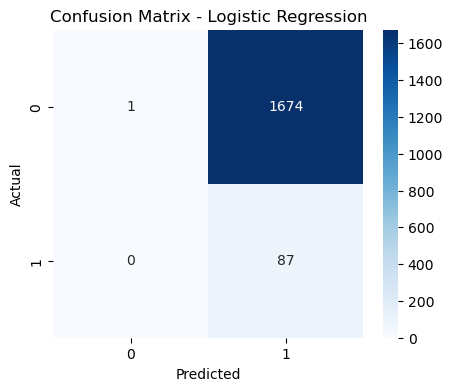

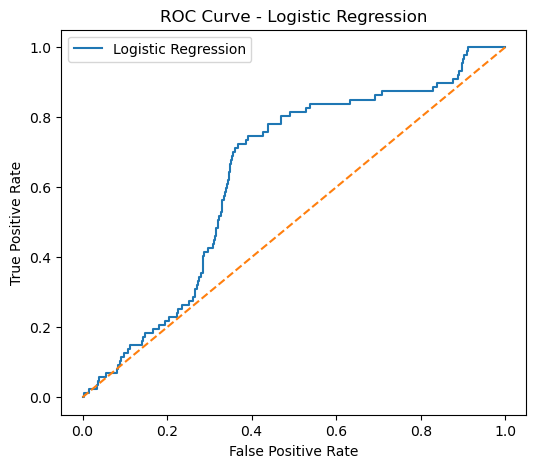

In [545]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("Logistic Regression", y_test, log_preds, log_probs)


## 12. Model 2: Random Forest

Random Forest can capture nonlinear relationships between technical indicators and crash risk.


Model: Random Forest
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1675
           1       0.02      0.01      0.01        87

    accuracy                           0.92      1762
   macro avg       0.48      0.49      0.49      1762
weighted avg       0.90      0.92      0.91      1762

ROC-AUC: 0.4342425802024361
Average Precision: 0.04205848217657696


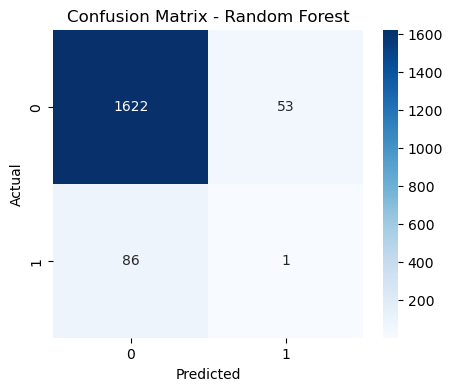

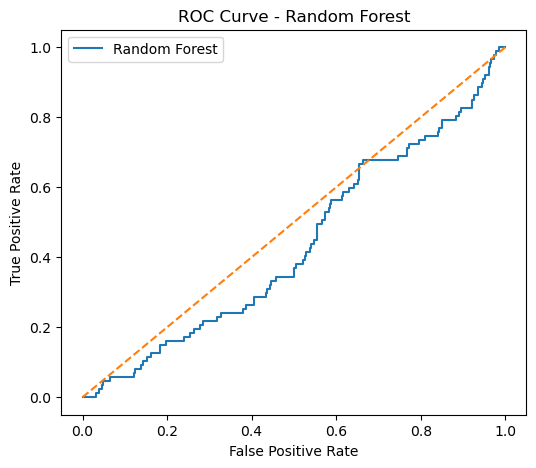

In [546]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest", y_test, rf_preds, rf_probs)


## 13. Model 3: XGBoost

XGBoost is a powerful gradient boosting method often used for structured data problems.


Model: XGBoost
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.71      0.81      1675
           1       0.02      0.11      0.03        87

    accuracy                           0.68      1762
   macro avg       0.48      0.41      0.42      1762
weighted avg       0.89      0.68      0.77      1762

ROC-AUC: 0.3802504717790358
Average Precision: 0.036692008143934814


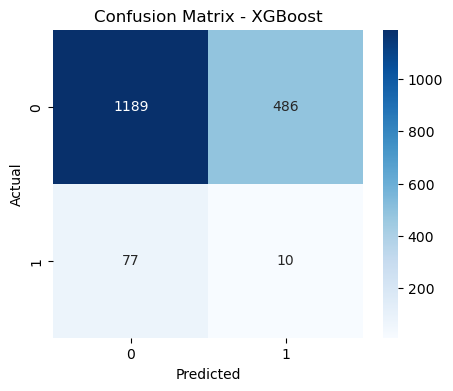

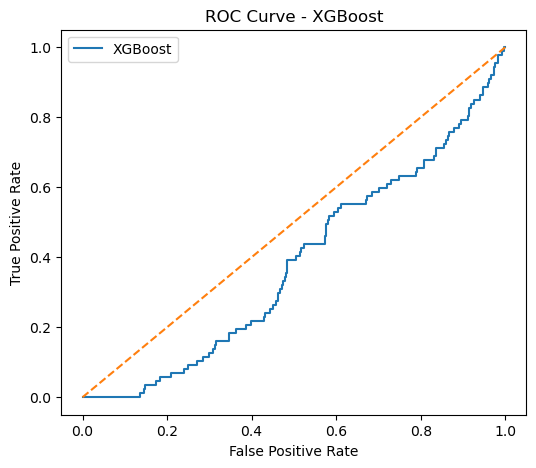

In [547]:
if XGBOOST_AVAILABLE:
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    xgb_model = XGBClassifier(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    )

    xgb_model.fit(X_train, y_train)

    xgb_preds = xgb_model.predict(X_test)
    xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

    evaluate_model("XGBoost", y_test, xgb_preds, xgb_probs)
else:
    print("XGBoost is not installed. Run: pip install xgboost")


## 14. Results Summary

The following table compares all models using metrics that are appropriate for rare-event classification. Average Precision is especially important because it focuses on the positive crash class under class imbalance.

In [548]:
results_df = pd.DataFrame(results).sort_values("Average Precision", ascending=False)
results_df.style.format({
    "ROC-AUC": "{:.3f}",
    "Average Precision": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}"
})


,Model,ROC-AUC,Average Precision,Precision,Recall,F1
1,Logistic Regression,0.636,0.069,0.049,1.000,0.094
0,Baseline - Majority Class,0.500,0.049,0.000,0.000,0.000
2,Random Forest,0.434,0.042,0.019,0.011,0.014
3,XGBoost,0.380,0.037,0.020,0.115,0.034


## 15. Walk-Forward Validation

A single train/test split can be sensitive to the specific market regime in the test period. To make the validation more robust, this section uses walk-forward validation with `TimeSeriesSplit`. Each fold trains on the past and tests on a later period, preserving the chronological order.

In [549]:
def walk_forward_validate(model_factory, X, y, model_name, n_splits=5, needs_scaling=False):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        # Embargo inside each fold to reduce target leakage from the future-return label.
        if len(train_idx) <= future_horizon:
            continue
        train_idx = train_idx[:-future_horizon]

        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        if y_te.nunique() < 2:
            # ROC-AUC is undefined when only one class appears in the test fold.
            continue

        model = model_factory()

        if needs_scaling:
            scaler = StandardScaler()
            X_tr_model = scaler.fit_transform(X_tr)
            X_te_model = scaler.transform(X_te)
        else:
            X_tr_model = X_tr
            X_te_model = X_te

        model.fit(X_tr_model, y_tr)
        y_prob = model.predict_proba(X_te_model)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        fold_results.append({
            "Model": model_name,
            "Fold": fold,
            "Test Start": X_te.index.min(),
            "Test End": X_te.index.max(),
            "ROC-AUC": roc_auc_score(y_te, y_prob),
            "Average Precision": average_precision_score(y_te, y_prob),
            "Precision": precision_score(y_te, y_pred, zero_division=0),
            "Recall": recall_score(y_te, y_pred, zero_division=0),
            "F1": f1_score(y_te, y_pred, zero_division=0)
        })

    return pd.DataFrame(fold_results)


wf_log = walk_forward_validate(
    lambda: LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
    X,
    y,
    "Logistic Regression",
    needs_scaling=True
)

wf_rf = walk_forward_validate(
    lambda: RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    X,
    y,
    "Random Forest"
)

walk_forward_results = pd.concat([wf_log, wf_rf], ignore_index=True)

if XGBOOST_AVAILABLE:
    wf_xgb = walk_forward_validate(
        lambda: XGBClassifier(
            n_estimators=400,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
            eval_metric="logloss",
            random_state=RANDOM_STATE
        ),
        X,
        y,
        "XGBoost"
    )
    walk_forward_results = pd.concat([walk_forward_results, wf_xgb], ignore_index=True)

walk_forward_results


,Model,Fold,Test Start,Test End,ROC-AUC,Average Precision,Precision,Recall,F1
0,Logistic Regression,1,1996-10-22,2002-08-21,0.434992,0.068043,0.068750,0.105769,0.083333
1,Logistic Regression,2,2002-08-22,2008-06-19,0.490081,0.056956,0.023873,0.574468,0.045840
2,Logistic Regression,3,2008-06-20,2014-04-17,0.666940,0.132320,0.087215,0.871287,0.158559
3,Logistic Regression,4,2014-04-21,2020-02-14,0.627731,0.065503,0.032877,1.000000,0.063660
4,Logistic Regression,5,2020-02-18,2025-12-16,0.657973,0.082198,0.055215,1.000000,0.104651
5,Random Forest,1,1996-10-22,2002-08-21,0.416156,0.061513,0.000000,0.000000,0.000000
6,Random Forest,2,2002-08-22,2008-06-19,0.529930,0.059037,0.079422,0.468085,0.135802
7,Random Forest,3,2008-06-20,2014-04-17,0.593980,0.097898,0.098901,0.178218,0.127208
8,Random Forest,4,2014-04-21,2020-02-14,0.566391,0.070934,0.064220,0.145833,0.089172
9,Random Forest,5,2020-02-18,2025-12-16,0.681658,0.093906,0.094059,0.234568,0.134276


## 14. Feature Importance


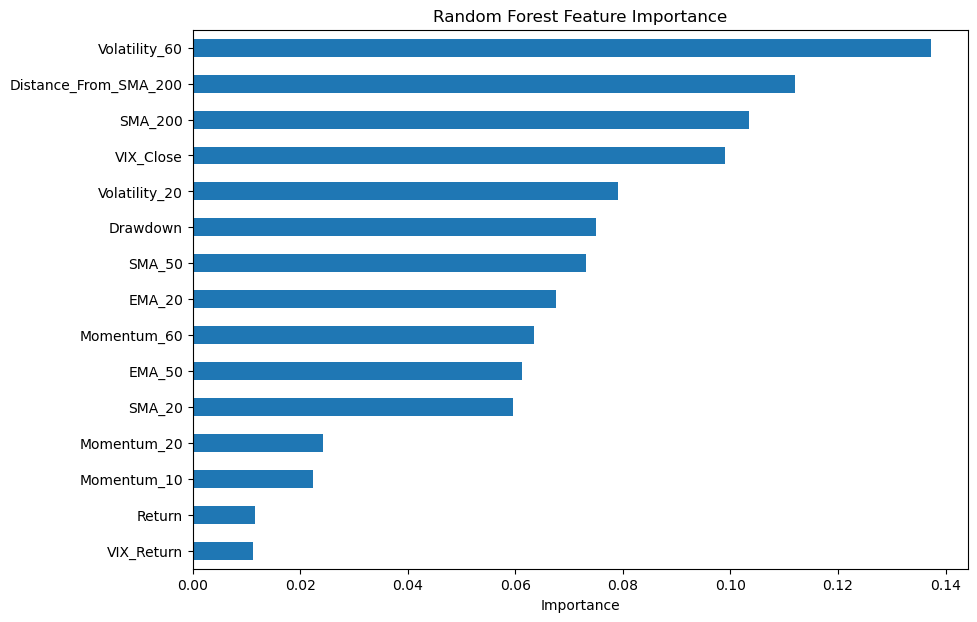

In [550]:
rf_importance = pd.Series(rf_model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(10, 7))
rf_importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()


## 17. Discussion

This project demonstrates the difficulty of predicting rare financial crash events. Since crashes are uncommon, accuracy alone is not an appropriate metric. Recall, precision, F1-score, ROC-AUC, and average precision provide more meaningful insight.

Important expected findings:

- VIX-related features should carry predictive information.
- Volatility and drawdown features are likely more useful than simple price levels.
- False negatives are more dangerous than false positives in risk management.
- Market regimes change, so historical relationships may not remain stable.


## 18. Limitations

- Market crashes are rare and the dataset is imbalanced.
- Historical relationships may not hold in future market regimes.
- Black Swan events are difficult or impossible to predict reliably.
- VIX data starts in 1990, limiting the historical sample.
- The model does not include macroeconomic variables, interest rates, credit spreads, or news sentiment.


## 19. Conclusion

This project shows that crash prediction is a difficult rare-event classification problem. The baseline model is useful as a sanity check because it demonstrates that high accuracy alone is not meaningful when crash events are rare.

The machine learning models are evaluated with ROC-AUC, Average Precision, Precision, Recall, and F1-score. Average Precision and Recall are especially important because the positive class is rare and missing a crash can be costly.

The added leakage gap makes the final train/test split more realistic because labels in the training set no longer depend on future prices from the test period. The walk-forward validation gives a more robust view of model behavior across different market regimes.

In practical use, this type of model should not be interpreted as a precise crash-prediction engine. It is better understood as a risk-warning tool that can highlight periods of increased market stress.

## 20. References

- Yahoo Finance. Historical market data for `^GSPC` and `^VIX`, accessed through the `yfinance` Python package.
- Aroussi, R. `yfinance` Python package documentation and GitHub repository.
- scikit-learn developers. `scikit-learn` documentation: Logistic Regression, Random Forest, DummyClassifier, TimeSeriesSplit, and classification metrics.
- Chen, T. and Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining.
- Chicago Board Options Exchange (CBOE). VIX Index methodology and overview.
- Standard references for classification metrics: precision, recall, F1-score, ROC-AUC, and precision-recall curves.